In [94]:
import numpy as np
import matplotlib.pyplot as plt
import fisheye

import importlib
importlib.reload(fisheye)

<module 'fisheye' from 'c:\\Users\\bglen\\Research\\XLZD\\Fisheye\\fisheye.py'>

In [92]:
camera = fisheye.Fisheye()

camera.PrintInfo()
camera.DefineSensor(pixel_size_mm=0.1, num_pixels_x=100, num_pixels_y=100)
camera.CalculateFocalLength()



Distance to object: 7.00 cm
Field of view radius: 30.00 cm
Field of view angle: 76.87 degrees
Projection type: stereographic
Array size: 10.00 mm x 10.00 mm
Max image radius: 5.00 mm
Pixel size: 0.10 mm
Number of pixels: 100 x 100


30.0


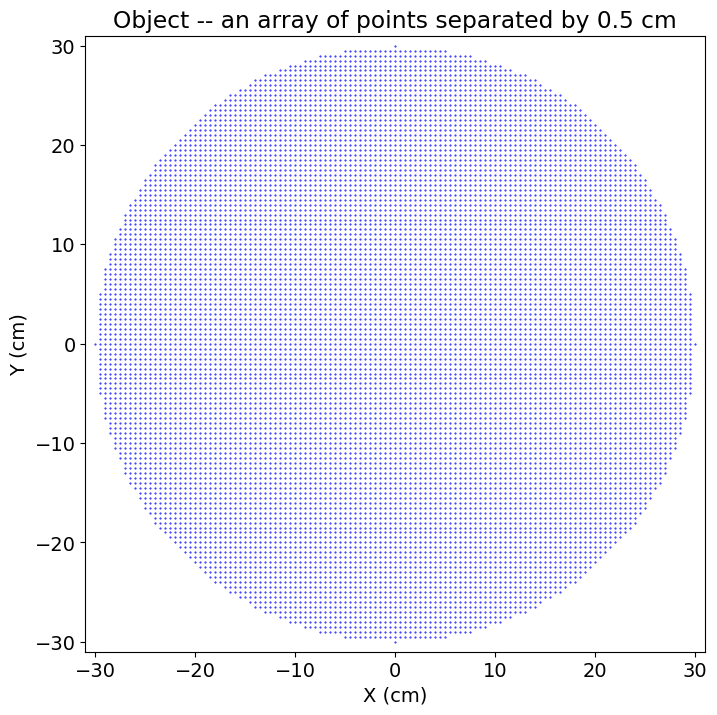

In [82]:
# Define my object as a grid of points in 2D space (the object plane), each weighted by one.
point_spacing_cm = 0.5 # cm
print(camera.field_of_view_radius_cm)
object_plane_x = np.arange(-camera.field_of_view_radius_cm, camera.field_of_view_radius_cm + point_spacing_cm, point_spacing_cm)
object_plane_y = np.arange(-camera.field_of_view_radius_cm, camera.field_of_view_radius_cm + point_spacing_cm, point_spacing_cm)

object_plane_X, object_plane_Y = np.meshgrid(object_plane_x, object_plane_y)
mask = np.sqrt(object_plane_X**2 + object_plane_Y**2) <= camera.field_of_view_radius_cm
object_plane_X = object_plane_X[mask]
object_plane_Y = object_plane_Y[mask]

plt.figure(figsize=(8, 8))
plt.rcParams['font.size'] = 14
plt.scatter(object_plane_X, object_plane_Y, s=0.2, color='blue')
plt.title('Object -- an array of points separated by {:.1f} cm'.format(point_spacing_cm))
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.xlim(-camera.field_of_view_radius_cm - 1, camera.field_of_view_radius_cm + 1)
plt.ylim(-camera.field_of_view_radius_cm - 1, camera.field_of_view_radius_cm + 1)
# plt.grid()

# Flatten the grid to get a list of points. the Z coordinate is just the distance to the object plane, which is constant for all points.
object_points_3d = np.column_stack((object_plane_X.flatten(), object_plane_Y.flatten(), np.ones(object_plane_X.size) * camera.distance_to_object_cm))
object_weights_3d = np.ones(object_points_3d.shape[0]) # All points have equal weight for now.

(-6.0, 6.0)

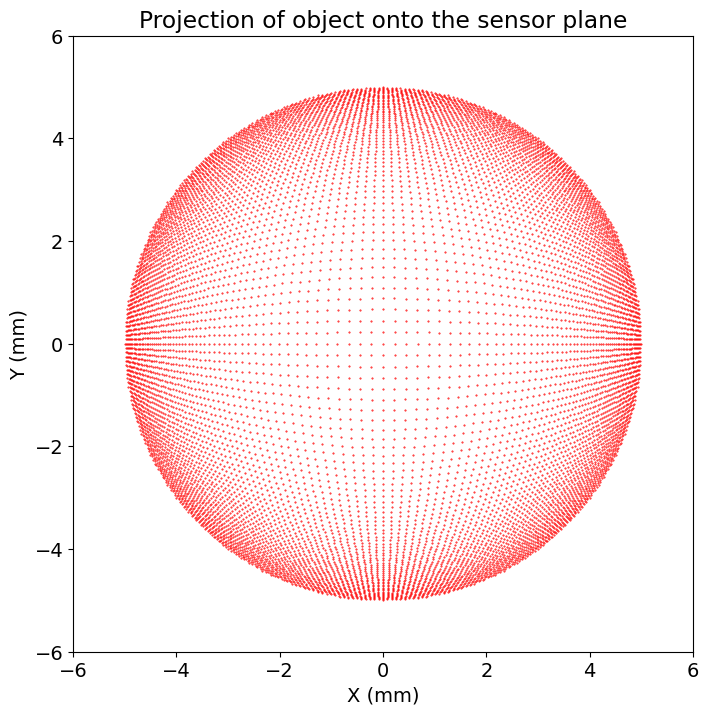

In [83]:
camera.DefineObject(object_points_3d, object_weights_3d)
camera.ProjectPoints()

# Plot the image points
plt.figure(figsize=(8, 8))
plt.rcParams['font.size'] = 14
plt.scatter(camera.image_points_2d_mm[:, 0], camera.image_points_2d_mm[:, 1], s=0.2, color='red')
plt.title('Projection of object onto the sensor plane')
plt.xlabel('X (mm)')
plt.ylabel('Y (mm)')
plt.xlim(-camera.sensor.max_image_radius_mm - 1, camera.sensor.max_image_radius_mm + 1)
plt.ylim(-camera.sensor.max_image_radius_mm - 1, camera.sensor.max_image_radius_mm + 1)

Text(0, 0.5, 'Pixel Y')

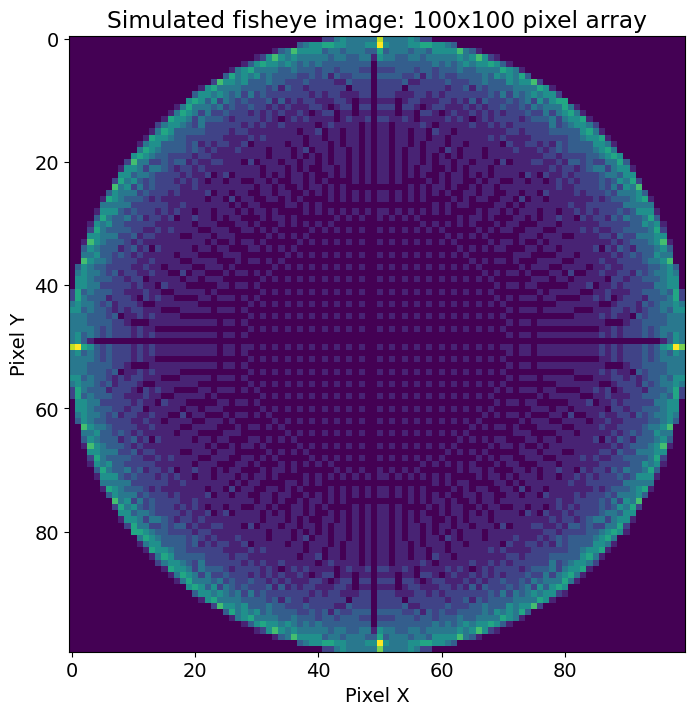

In [87]:
camera.ProduceImage()

image = camera.sensor_image
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title('Simulated fisheye image: 100x100 pixel array')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')

Distance to object: 7.00 cm
Field of view radius: 30.00 cm
Field of view angle: 76.87 degrees
Projection type: stereographic
Array size: 10.24 mm x 10.24 mm
Max image radius: 5.12 mm
Pixel size: 0.01 mm
Number of pixels: 1024 x 1024


Text(0, 0.5, 'Pixel Y')

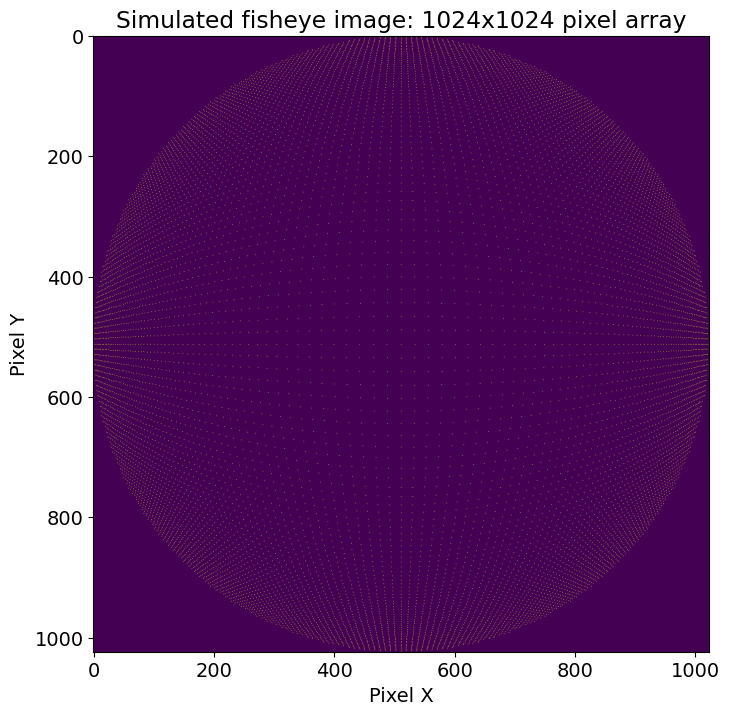

In [88]:
# Do the same thing but with a higher resolution sensor and smaller pixel size to see the difference.
# Here the pixels are 10um and the sensor is 1024x1024 pixels.

camera_MP = fisheye.Fisheye()

camera_MP.PrintInfo()

camera_MP.DefineSensor(pixel_size_mm=0.01, num_pixels_x=1024, num_pixels_y=1024)
camera_MP.CalculateFocalLength()
camera_MP.DefineObject(object_points_3d, object_weights_3d)
camera_MP.ProjectPoints()
camera_MP.ProduceImage()

image = camera_MP.sensor_image
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title('Simulated fisheye image: 1024x1024 pixel array')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')

(850.0, 900.0)

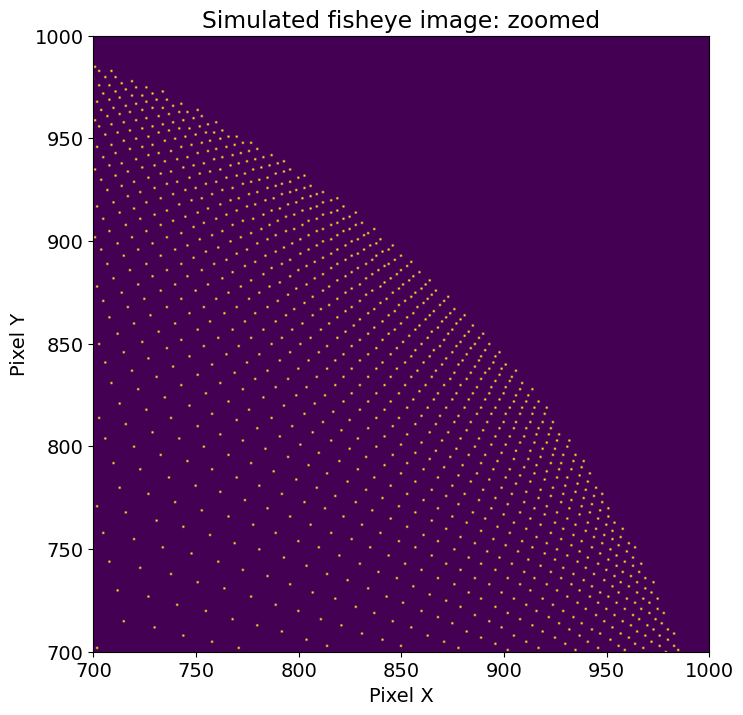

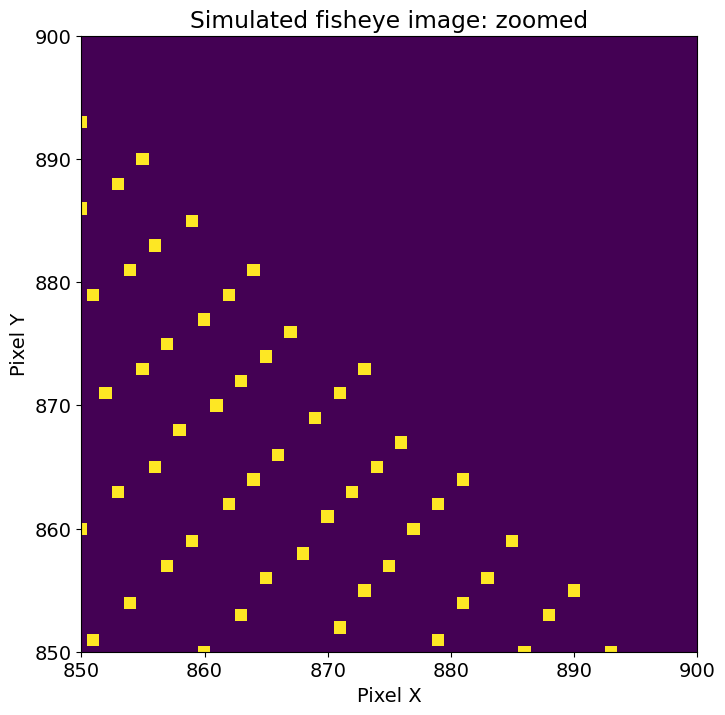

In [90]:
plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title('Simulated fisheye image: zoomed')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.xlim(700,1000)
plt.ylim(700,1000)


plt.figure(figsize=(8, 8))
plt.imshow(image)
plt.title('Simulated fisheye image: zoomed')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.xlim(850,900)
plt.ylim(850,900)

Array size: 10.24 mm x 10.24 mm
Max image radius: 5.12 mm
Pixel size: 0.01 mm
Number of pixels: 1024 x 1024
{'n_input_points': 50, 'n_valid_points': 50, 'n_generated_photons': 2500, 'count_mode': 'deterministic', 'kernel_sigma_um': 1000.0, 'z_range_mm': [0.0, 0.1], 'rng_seed': 123}


(800.0, 900.0)

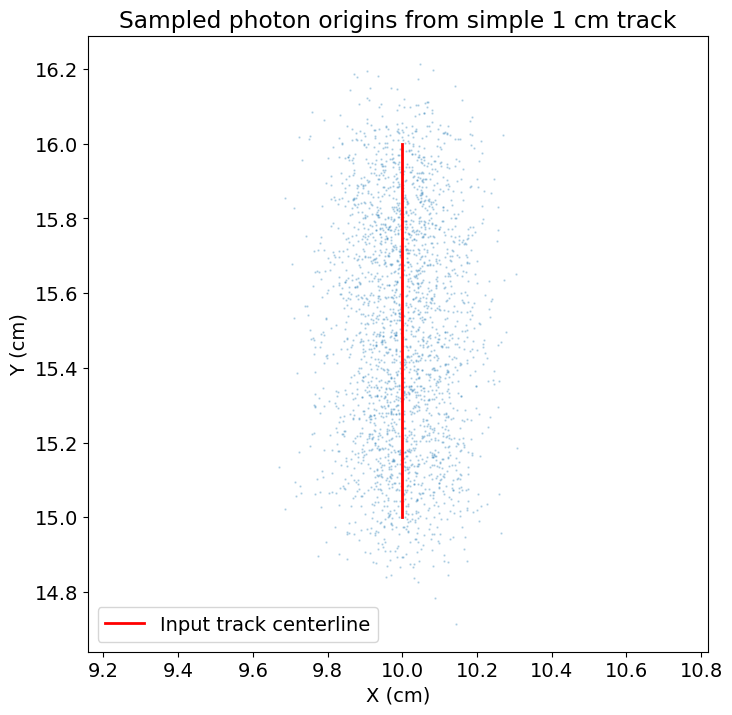

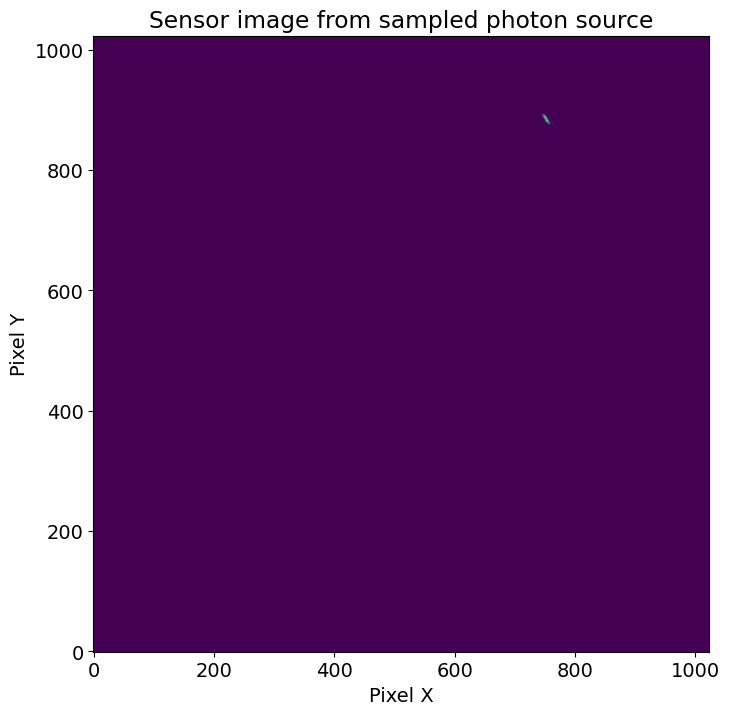

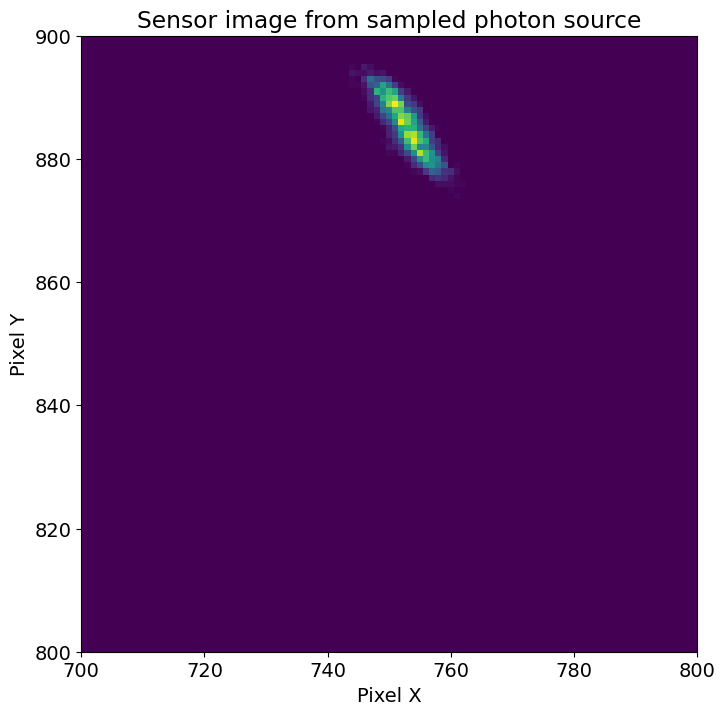

In [103]:
# Simple test: track from (x, y) = (10 cm, 15 cm) to (10 cm, 16 cm)
import importlib
importlib.reload(fisheye)

# Build a short vertical track in +y with uniform deposited energy per sample point.
n_track_points = 50
track_y_cm = np.linspace(15.0, 16.0, n_track_points)
track_x_cm = np.full(n_track_points, 10.0)
track_E = np.ones(n_track_points)
track_xyE = np.column_stack((track_x_cm, track_y_cm, track_E))

camera_track = fisheye.Fisheye(field_of_view_radius_cm=30.0)
camera_track.DefineSensor(pixel_size_mm=0.01, num_pixels_x=1024, num_pixels_y=1024)
camera_track.CalculateFocalLength()

source_out = camera_track.CreatePhotonSourceFromTrack(
    track_xyE,
    photons_per_energy=50.0,
    kernel_sigma_um=1000,
    z_min_mm=0.0,
    z_max_mm=0.1,
    count_mode='deterministic',
    rng_seed=123
 )
print(source_out['metadata'])

# Visualize photon origins in object space (x-y).
plt.figure(figsize=(8, 8))
plt.scatter(camera_track.object_points_3d[:, 0], camera_track.object_points_3d[:, 1], s=0.5, alpha=0.25)
plt.plot(track_x_cm, track_y_cm, color='red', linewidth=2, label='Input track centerline')
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.title('Sampled photon origins from simple 1 cm track')
plt.legend()
plt.axis('equal')

camera_track.ProjectPoints()
camera_track.ProduceImage()

plt.figure(figsize=(8, 8))
plt.imshow(camera_track.sensor_image, origin='lower')
plt.title('Sensor image from sampled photon source')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
# plt.colorbar(label='Photon count')


plt.figure(figsize=(8, 8))
plt.imshow(camera_track.sensor_image, origin='lower')
plt.title('Sensor image from sampled photon source')
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
plt.xlim(700,800)
plt.ylim(800,900)


Array size: 10.24 mm x 10.24 mm
Max image radius: 5.12 mm
Pixel size: 0.01 mm
Number of pixels: 1024 x 1024
{'n_input_points': 500, 'n_valid_points': 500, 'n_generated_photons': 25000, 'count_mode': 'deterministic', 'kernel_sigma_um': 1000.0, 'z_range_mm': [0.0, 0.1], 'rng_seed': 123}


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.





(array([880], dtype=int64), array([756], dtype=int64))


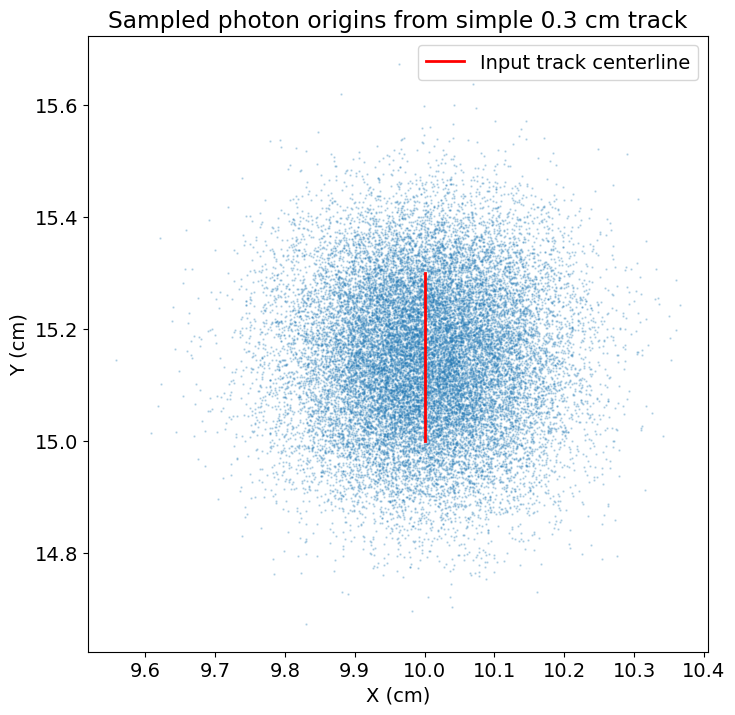

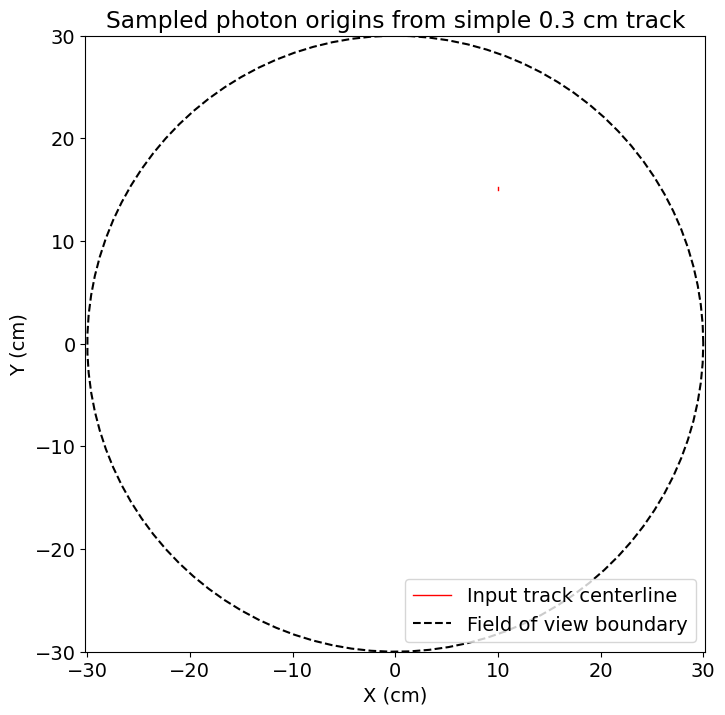

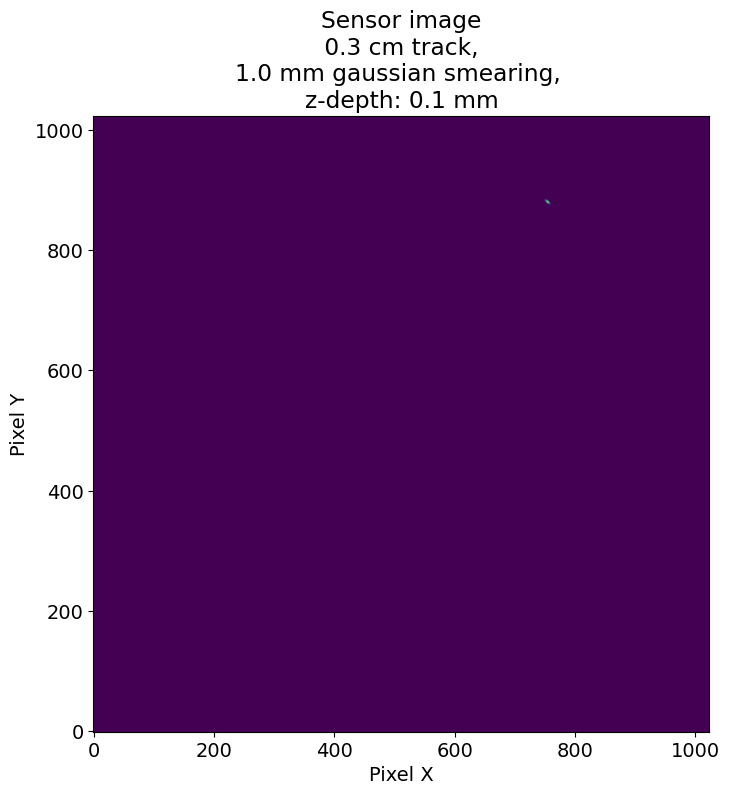

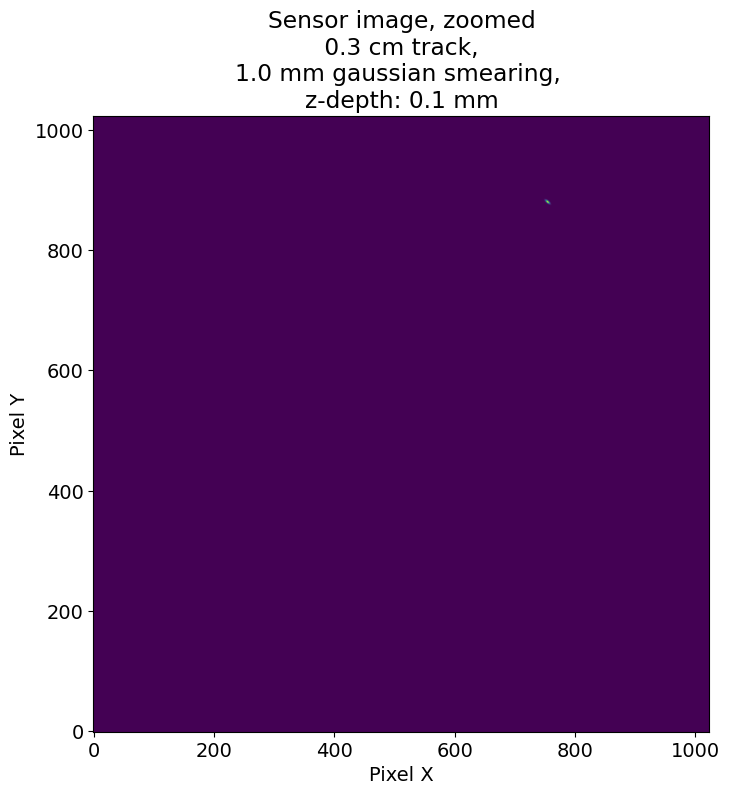

In [131]:
# Simple test: track from (x, y) = (10 cm, 15 cm) to (10 cm, 16 cm)
import importlib
importlib.reload(fisheye)

kernel_sigma_um = 1000
z_min_mm = 0.0
z_max_mm = 0.1
track_offset_x_cm = 10.0
track_offset_y_cm = 15.0

# Build a short vertical track in +y with uniform deposited energy per sample point.
n_track_points = 500
track_y_cm = np.linspace(0., 0.3, n_track_points) + track_offset_y_cm
track_x_cm = np.full(n_track_points, track_offset_x_cm)
track_E = np.ones(n_track_points)
track_xyE = np.column_stack((track_x_cm, track_y_cm, track_E))

camera_track = fisheye.Fisheye(field_of_view_radius_cm=30.0)
camera_track.DefineSensor(pixel_size_mm=0.01, num_pixels_x=1024, num_pixels_y=1024)
camera_track.CalculateFocalLength()



source_out = camera_track.CreatePhotonSourceFromTrack(
    track_xyE,
    photons_per_energy=50.0,
    kernel_sigma_um=kernel_sigma_um,
    z_min_mm=0.0,
    z_max_mm=0.1,
    count_mode='deterministic',
    rng_seed=123
 )
print(source_out['metadata'])

# Visualize photon origins in object space (x-y).
plt.figure(figsize=(8, 8))
plt.scatter(camera_track.object_points_3d[:, 0], camera_track.object_points_3d[:, 1], s=0.5, alpha=0.25)
plt.plot(track_x_cm, track_y_cm, color='red', linewidth=2, label='Input track centerline')
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.title('Sampled photon origins from simple {:2.2} cm track'.format(track_y_cm[-1] - track_y_cm[0]))
plt.legend()


# Visualize photon origins in object space (x-y).
plt.figure(figsize=(8, 8))
# plt.scatter(camera_track.object_points_3d[:, 0], camera_track.object_points_3d[:, 1], s=0.5, alpha=0.25)
plt.plot(track_x_cm, track_y_cm, color='red', linewidth=1, label='Input track centerline')
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.title('Sampled photon origins from simple {:2.2} cm track'.format(track_y_cm[-1] - track_y_cm[0]))
plt.axis('equal')
plt.xlim(-30,30)
plt.ylim(-30,30)
#Plot a circle with radius 30cm, with a dashed black line to show the field of view boundary.
theta = np.linspace(0, 2*np.pi, 100)
x_circle = camera_track.field_of_view_radius_cm * np.cos(theta)
y_circle = camera_track.field_of_view_radius_cm * np.sin(theta)
plt.plot(x_circle, y_circle, color='black', linestyle='--', label='Field of view boundary')
plt.legend(loc='lower right')

camera_track.ProjectPoints()
camera_track.ProduceImage()

plt.figure(figsize=(8, 8))
plt.imshow(camera_track.sensor_image, origin='lower')
plt.title('Sensor image\n {:2.2} cm track, \n{:2.1f} mm gaussian smearing, \nz-depth: {:2.1f} mm'.format(track_y_cm[-1] - track_y_cm[0], kernel_sigma_um/1000, z_max_mm-z_min_mm))
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
# plt.colorbar(label='Photon count')


plt.figure(figsize=(8, 8))
plt.imshow(camera_track.sensor_image, origin='lower')
plt.title('Sensor image, zoomed\n {:2.2} cm track, \n{:2.1f} mm gaussian smearing, \nz-depth: {:2.1f} mm'.format(track_y_cm[-1] - track_y_cm[0], kernel_sigma_um/1000, z_max_mm-z_min_mm))
plt.xlabel('Pixel X')
plt.ylabel('Pixel Y')
# Need to get xlim and ylim from the image points to zoom in on the track.
# sensor_image is a 2D array of the pixel weights. I need the x and y indices of the maximum pixel
track_image_points = camera_track.image_points_2d_mm
# print(camera_track.sensor_image)

print('\n\n')

print(np.where(camera_track.sensor_image == camera_track.sensor_image.max()))
